## 1- Import

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")


## 2- Load

In [5]:
df = pd.read_csv("data/processed/fifa21_clean.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18979 entries, 0 to 18978
Data columns (total 98 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Nationality        18979 non-null  object 
 1   Name               18979 non-null  object 
 2   Age                18979 non-null  int64  
 3   OVA                18979 non-null  int64  
 4   POT                18979 non-null  int64  
 5   ID                 18979 non-null  int64  
 6   Height             18979 non-null  float64
 7   Weight             18979 non-null  float64
 8   foot               18979 non-null  object 
 9   BOV                18979 non-null  int64  
 10  BP                 18979 non-null  object 
 11  Growth             18979 non-null  int64  
 12  Joined             18979 non-null  object 
 13  Value              18979 non-null  float64
 14  Wage               18979 non-null  float64
 15  Release Clause     18979 non-null  float64
 16  Attacking          189

## 3- Define features 

In [6]:
y = df["Value"] # since we are predicting player value :D

X = df.drop(columns=[
    "Name",
    "ID",

    "Nationality",
    "BP",
    "foot",
    "Joined",

    # Target + leakage
    "Value",
    "Wage",
    "Release Clause"
])
X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18979 entries, 0 to 18978
Data columns (total 89 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                18979 non-null  int64  
 1   OVA                18979 non-null  int64  
 2   POT                18979 non-null  int64  
 3   Height             18979 non-null  float64
 4   Weight             18979 non-null  float64
 5   BOV                18979 non-null  int64  
 6   Growth             18979 non-null  int64  
 7   Attacking          18979 non-null  int64  
 8   Crossing           18979 non-null  int64  
 9   Finishing          18979 non-null  int64  
 10  Heading Accuracy   18979 non-null  int64  
 11  Short Passing      18979 non-null  int64  
 12  Volleys            18979 non-null  int64  
 13  Skill              18979 non-null  int64  
 14  Dribbling          18979 non-null  int64  
 15  Curve              18979 non-null  int64  
 16  FK Accuracy        189

## 4- Train-Test Split

In [7]:
# checking for categorical columns (we are supposed to use numerical only for regression)
X.select_dtypes(include=["object"]).columns

Index(['A/W', 'D/W', 'Team', 'Primary_Position', 'Position_Category',
       'Age_Category'],
      dtype='object')

In [8]:
# One hot encode remaining categorical columns
X = pd.get_dummies(X, drop_first=True)

In [9]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

## 5- Train All Models 

In [10]:
# Define models 
lr = LinearRegression()
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
svr = SVR(kernel='rbf', C=1000, gamma='auto', epsilon=0.1)
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)


lr.fit(X_train_scaled, y_train)
dt.fit(X_train, y_train) # Decision Tree doesn't need scaling bec it makes splits based on feature values
svr.fit(X_train_scaled, y_train_scaled) # SVR needs scaled X and y
rf.fit(X_train, y_train) # Random Forest doesn't need scaling bec its just an ensemble of trees

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 6- Predictions

In [11]:
lr_pred = lr.predict(X_test_scaled)
dt_pred = dt.predict(X_test)
svr_pred_scaled = svr.predict(X_test_scaled)
svr_pred = scaler_y.inverse_transform(svr_pred_scaled.reshape(-1, 1)).ravel() # SVR predictions need to be inverse transformed
rf_pred = rf.predict(X_test)

## 7- Evaluation Function 

In [12]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"----- {model_name} -----")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2 Score:", r2_score(y_test, y_pred))
    print()


## 8- Evaluate All

In [13]:
evaluate_model(y_test, lr_pred, "Linear Regression")
evaluate_model(y_test, dt_pred, "Decision Tree")
evaluate_model(y_test, svr_pred, "Support Vector Regression (SVR)")
evaluate_model(y_test, rf_pred, "Random Forest")

----- Linear Regression -----
MAE: 97786.89679095818
MSE: 42534160909.50448
RMSE: 206238.1170140585
R2 Score: 0.9984575335752202

----- Decision Tree -----
MAE: 28815.583980946063
MSE: 243573047032.44943
RMSE: 493531.20168075437
R2 Score: 0.9911670234231678

----- Support Vector Regression (SVR) -----
MAE: 371041.2839660588
MSE: 555807154986.9451
RMSE: 745524.7514247566
R2 Score: 0.9798441098428211

----- Random Forest -----
MAE: 23998.203132117294
MSE: 230995281552.58472
RMSE: 480619.68494079047
R2 Score: 0.9916231457619327



## 9- Compare results

In [14]:
RESULTS = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "SVR", "Random Forest"],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, svr_pred),
        r2_score(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, svr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ]
})
RESULTS

,Model,R2 Score,RMSE
0,Linear Regression,0.998458,206238.117014
1,Decision Tree,0.991167,493531.201681
2,SVR,0.979844,745524.751425
3,Random Forest,0.991623,480619.684941


## 10- Visualization of Model Performance

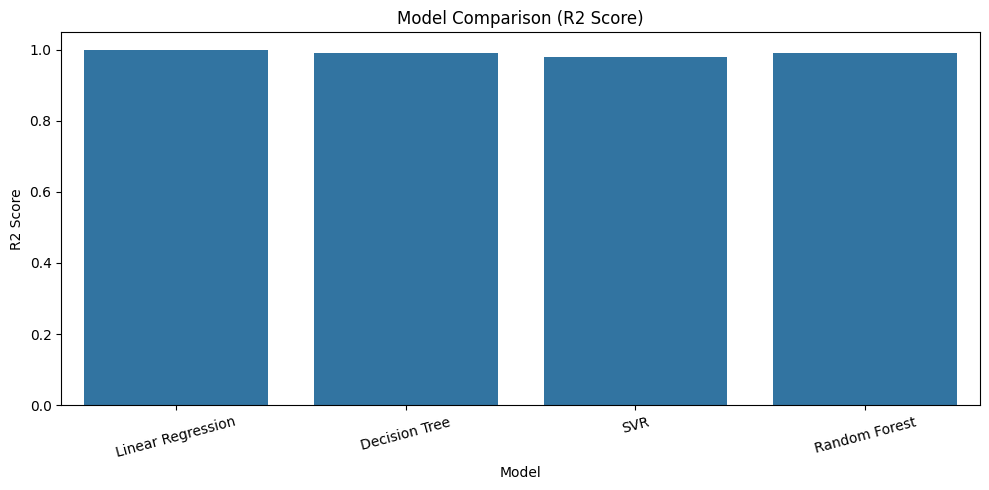

In [15]:
plt.figure(figsize=(10, 5))
sns.barplot(x="Model", y="R2 Score", data=RESULTS)
plt.title("Model Comparison (R2 Score)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## EXTRA: Save Model

In [16]:
import joblib
import os
models_path = "models"
os.makedirs(models_path, exist_ok=True)

joblib.dump(lr, os.path.join(models_path, "linear_regression.pkl"))
joblib.dump(dt, os.path.join(models_path, "decision_tree.pkl"))
joblib.dump(svr, os.path.join(models_path, "svr.pkl"))
joblib.dump(rf, os.path.join(models_path, "random_forest.pkl"))
joblib.dump(scaler_X, os.path.join(models_path, "scaler_X.pkl"))
joblib.dump(scaler_y, os.path.join(models_path, "scaler_y.pkl"))  

print("All models and scalers saved successfully!")

All models and scalers saved successfully!
